In [179]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from scipy.stats import ks_2samp
from uncertainties import unumpy as unp
from uncertainties import ufloat
from uncertainties.unumpy import log as ulog
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

from astropy.coordinates import SkyCoord
import astropy.units as u

import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FormatStrFormatter
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import seaborn as sns

labelsize=12
palette = 'viridis'
font = {'family': 'serif', 'color':  'black', 'weight': 'normal','size': 14}
font_cb = {'family': 'serif', 'color':  'black', 'weight': 'normal','size': 12}


In [3]:
data = pd.read_csv('Dados\data.csv', index_col='Cluster')
df = pd.read_csv(r'Dados\results.csv', index_col='Cluster')
benchmark_subsample = pd.read_csv(r'Dados\benchmark_subsample.csv', index_col='Cluster')

In [356]:


data_sorted = data.sort_values(by='mass_system').reset_index(drop=True)

binarias = data_sorted[data_sorted.q>0]
singles = data_sorted[data_sorted.q==0]

n_div = 10

subconjuntos_all_systems = np.array_split(data_sorted, n_div)
subconjuntos_singles = np.array_split(singles, n_div)
subconjuntos_binarias = np.array_split(binarias, n_div)

# Listas para armazenar os resultados
masses = []
mass_errors = []

radius_rh = []
radius_rh_errors = []

mean_q = []

binary_system_masses = []
single_system_masses = []

binary_system_r_rh = []
single_system_r_rh = []

# Loop por grupo
for i in range(0, n_div):
    
    # _________________Massa média com incerteza__________________________________
    
    #All systems
    mass_values = subconjuntos_all_systems[i].mass_system
    mass_mean = mass_values.mean()
    masses.append(mass_mean)
    mass_errors.append(np.std(mass_values)/np.sqrt(len(mass_values)))
    
    #Singles
    mass_values = subconjuntos_singles[i].mass_system
    mass_mean = mass_values.mean()
    single_system_masses.append(mass_mean)    
    
    #Binaries
    
    mass_values = subconjuntos_binarias[i].mass_system
    mass_mean = mass_values.mean()
    binary_system_masses.append(mass_mean) 
    

    #____________________ r/rh médio com incerteza __________________________________________
    
    # All systems
    rrh_values = subconjuntos_all_systems[i]['r/rh']
    rrh_mean = rrh_values.mean()
    radius_rh.append(rrh_mean)
    radius_rh_errors.append(np.std(rrh_values)/np.sqrt(len(rrh_values)))

    # Singles
    
    rrh_values = unumpy.uarray(subconjuntos_singles[i]['r/rh'], subconjuntos_singles[i]['e_r/rh'])
    rrh_mean = rrh_values.mean()
    single_system_r_rh.append(rrh_mean.nominal_value)

    
    
    # Binaries
    
    rrh_values = unumpy.uarray(subconjuntos_binarias[i]['r/rh'], subconjuntos_binarias[i]['e_r/rh'])
    rrh_mean = rrh_values.mean()
    binary_system_r_rh.append(rrh_mean.nominal_value)
    
    
    # Razão de massa média dos binários
    mean_q.append(subconjuntos_all_systems[i][subconjuntos_all_systems[i].q>0]['q'].mean())

# Converte listas para arrays numpy
masses = np.array(masses)
mass_errors = np.array(mass_errors)

radius_rh = np.array(radius_rh)
radius_rh_errors = np.array(radius_rh_errors)

mean_q = np.array(mean_q)

binary_system_masses = np.array(binary_system_masses)
single_system_masses = np.array(single_system_masses)

binary_system_r_rh = np.array(binary_system_r_rh)
single_system_r_rh = np.array(single_system_r_rh)


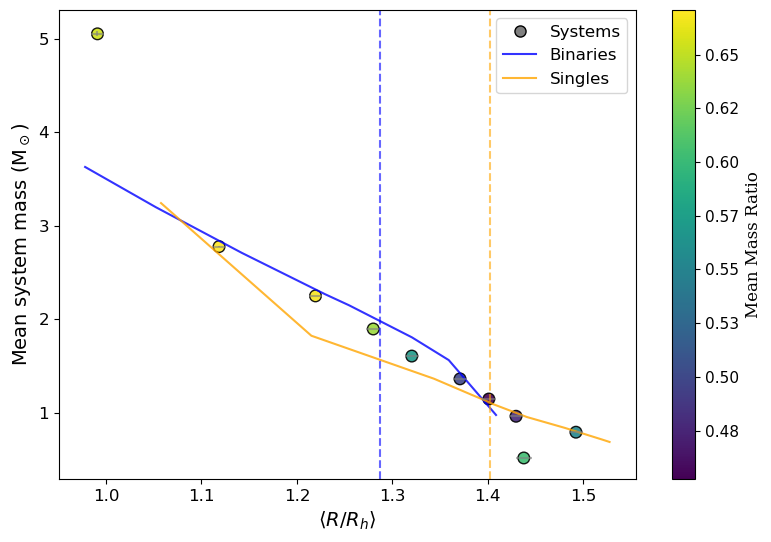

In [359]:
fig, ax = plt.subplots(figsize=(8, 6))

# Suavizações LOWESS
y_bin = sm.nonparametric.lowess(binary_system_masses, binary_system_r_rh, frac=0.5)
ax.plot(y_bin[:, 0], y_bin[:, 1], color='blue', alpha=0.8, label='Binaries')

y_sing = sm.nonparametric.lowess(single_system_masses, single_system_r_rh, frac=0.5)
ax.plot(y_sing[:, 0], y_sing[:, 1], color='orange', alpha=0.8, label='Singles')

# Dispersão com cor pelo mean_q
sc = ax.scatter(radius_rh, masses, c=mean_q, cmap='viridis', s=70, edgecolor='k', alpha=0.9,)
# Criar entrada personalizada para a legenda do scatter
scatter_proxy = mlines.Line2D([], [], linestyle='None', marker='o',
                              color='k', markerfacecolor='gray', 
                              markersize=8, label='Systems')




# Barras de erro
ax.errorbar(radius_rh, masses, xerr = radius_rh_errors, yerr=mass_errors, fmt='none', ecolor='gray', alpha=0.6)

# Linhas de mediana
ax.axvline(np.median(single_system_r_rh), ls='--', color='orange', alpha=0.6)
ax.axvline(np.median(binary_system_r_rh), ls='--', color='blue', alpha=0.6)

# Colorbar
norm = plt.Normalize(min(mean_q), max(mean_q))
smappable = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
smappable.set_array([])
cbar = plt.colorbar(smappable)
cbar.set_label('Mean Mass Ratio', fontdict=font_cb)
cbar.ax.tick_params(labelsize=11)
cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

# Labels e estilos
ax.set_xlabel(r'$\langle R/R_h \rangle$', fontdict=font)
ax.set_ylabel(r'$\mathrm{Mean \  system \ mass \ (M_\odot)}$', fontdict=font)
ax.tick_params(axis='both', labelsize=labelsize)

# Legenda
ax.legend(handles=[scatter_proxy] + ax.get_legend_handles_labels()[0], fontsize=12)

# Layout ajustado
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


In [292]:
subconjuntos_all_systems[-1][['mass_system', 'e_mass_system',  'r/rh']]

,mass_system,e_mass_system,r/rh
137270,3.176127,0.056646,0.560994
137271,3.176159,0.054582,0.861502
137272,3.176254,0.163651,2.722439
137273,3.176315,0.385585,0.233233
137274,3.176361,0.073029,0.412983
...,...,...,...
152517,55.781682,0.805482,0.314537
152518,57.951533,0.749538,0.259002
152519,58.933817,15.596183,0.836957
152520,63.295193,12.466939,1.065839


In [300]:
data.sort_values(by='mass', ascending=False)[['mass','er_mass', 'comp_mass', 'er_comp_mass']].head(15)

,mass,er_mass,comp_mass,er_comp_mass
Cluster,,,,
Bica_2,36.069716,0.262291,30.425772,0.662011
Bica_2,35.515122,5.609036,14.457547,7.729369
Bica_2,33.257177,6.357575,30.038016,10.724076
Bica_2,32.701249,7.661088,26.232567,13.584868
Bica_2,29.767470,0.415431,28.184062,0.623879
Bica_2,29.231330,0.395169,26.550352,0.701885
Bica_2,28.638671,0.433953,26.368132,0.704924
BH_205,24.992909,0.004419,0.000000,0.000000
Bica_2,23.929838,0.009326,0.000000,0.000000


In [241]:
def agrupar_medias(data, filtro, ordenar_por, n_grupos=10):
    """    
    Parâmetros:
        data (DataFrame): dataframe original
        filtro (Series): condição para filtrar linhas
        ordenar_por (str): nome da coluna usada para ordenar os dados
        n_grupos (int): número de grupos iguais (default=10)
    
    Retorna:
        dicionário com arrays das médias e erros:
            - r_rh
            - e_r_rh
            - mass
            - e_mass
            - q_mean, caso q>0
    """
    
    # Filtra e ordena os dados
    dados = data[filtro].sort_values(by=ordenar_por).reset_index(drop=True)

    # Divide em grupos iguais
    grupos = np.array_split(dados, n_grupos)

    # Listas para armazenar resultados
    r_rh_medias = []
    e_r_rh = []
    mass_medias = []
    e_mass = []
    mean_q = []

    for grupo in grupos:
        if len(grupo) > 0:
            r_vals = grupo['r/rh'].values
            r_errs = grupo['e_r/rh'].values
            r_rh = unp.uarray(r_vals, r_errs).mean()
            r_rh_medias.append(r_rh.nominal_value)
            e_r_rh.append(r_rh.std_dev)

            m_vals = grupo['mass_system'].values
            m_errs = grupo['e_mass_system'].values
            mass = unp.uarray(m_vals, m_errs).mean()
            mass_medias.append(mass.nominal_value)
            e_mass.append(mass.std_dev)
            
            mean_q.append(grupo['q'].mean())
            
            

    return {
        'r_rh': np.array(r_rh_medias),
        'e_r_rh': np.array(e_r_rh),
        'mass': np.array(mass_medias),
        'e_mass': np.array(e_mass),
        'mean_q': np.array(mean_q)
    }


res_singulares = agrupar_medias(data, filtro=(data.q == 0), ordenar_por='mass_system', n_grupos=10)

res_binarios = agrupar_medias(data, filtro=(data.q > 0), ordenar_por='mass_system', n_grupos=10)

res_all = agrupar_medias(data, filtro= np.ones(len(data), dtype=bool) , ordenar_por='mass_system', n_grupos=10)


In [249]:
res_binarios['r_rh'].mean()

1.2519317137823145

In [247]:
res_singulares['r_rh'].mean()

1.3771075704863542

# Tempo de relaxamento

In [56]:
resultados =pd.DataFrame(index=df.index)

resultados[r'$f_b$'] = unumpy.uarray(df['bin_frac'], df['er_bin_frac'])
resultados[r'$t_{relax}$ [Myr]'] = unumpy.uarray(df['t_relax']/1e6, df['er_t_relax']/1e6)
resultados[r'$\tau$'] = unumpy.uarray(df['tau'], df['er_tau'])
resultados[r'$R_h$'] = df['rh']
def format_ufloat(x):
    return f"{x.nominal_value:.2f} ± {x.std_dev:.2f}"
tabela_formatada = resultados.copy()

for col in resultados.columns:
    if resultados[col].dtype == 'O':  # coluna com ufloat
        tabela_formatada[col] = resultados[col].apply(format_ufloat)
    else:
        tabela_formatada[col] = resultados[col].map("{:.2f}".format)
        
latex = tabela_formatada.to_latex(index=True, escape=False)


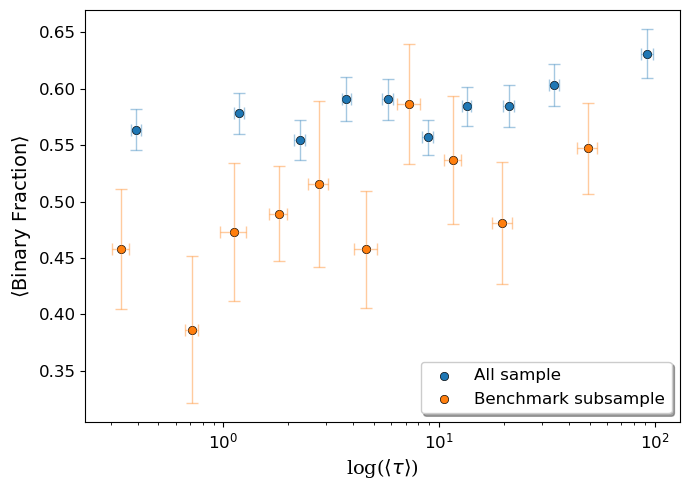

In [159]:
subconjuntos = np.array_split(df.sort_values(by='tau'), 10)
subconjuntos_benchmark = np.array_split(benchmark_subsample.sort_values(by='tau'), 10)

tau_mean = []
tau_benchmark_mean = []
bin_frac_mean = []
bin_frac_benchmark_mean = []

for i in range(len(subconjuntos)):
    tau_vals = subconjuntos[i]["tau"].values
    tau_errs = subconjuntos[i]["e_tau"].values
    tau_ufloats = unumpy.uarray(tau_vals, tau_errs)
    tau_mean.append((tau_ufloats).mean())

    tau_b_vals = subconjuntos_benchmark[i]["tau"].values
    tau_b_errs = subconjuntos_benchmark[i]["e_tau"].values
    tau_b_ufloats = unumpy.uarray(tau_b_vals, tau_b_errs)
    tau_benchmark_mean.append((tau_b_ufloats).mean())

    # bin_frac y er_bin_frac
    bf_vals = subconjuntos[i]["bin_frac"].values
    bf_errs = subconjuntos[i]["e_bin_frac"].values
    bf_ufloats = unumpy.uarray(bf_vals, bf_errs)
    bin_frac_mean.append((bf_ufloats).mean())

    bf_b_vals = subconjuntos_benchmark[i]["bin_frac"].values
    bf_b_errs = subconjuntos_benchmark[i]["e_bin_frac"].values
    bf_b_ufloats = unumpy.uarray(bf_b_vals, bf_b_errs)
    bin_frac_benchmark_mean.append((bf_b_ufloats).mean())

tau_mean = np.array(tau_mean)
tau_benchmark_mean = np.array(tau_benchmark_mean)
bin_frac_mean = np.array(bin_frac_mean)
bin_frac_benchmark_mean = np.array(bin_frac_benchmark_mean)

x = unumpy.nominal_values(tau_mean)
y = unumpy.nominal_values(bin_frac_mean)
xerr = unumpy.std_devs(tau_mean)
yerr = unumpy.std_devs(bin_frac_mean)

x_bench = unumpy.nominal_values(tau_benchmark_mean)
y_bench = unumpy.nominal_values(bin_frac_benchmark_mean)
xerr_bench = unumpy.std_devs(tau_benchmark_mean)
yerr_bench = unumpy.std_devs(bin_frac_benchmark_mean)

fig, ax = plt.subplots(figsize=(7, 5))

# Scatterplot para todos os dados
sns.scatterplot(x=x, y=y, ax=ax, label='All sample', color='tab:blue', edgecolor='k',)
ax.errorbar(x, y,xerr=xerr, yerr=yerr,fmt='none',ecolor='tab:blue',alpha=0.4,capsize=4,elinewidth=1,)

# Scatterplot para benchmark
sns.scatterplot(x=x_bench, y=y_bench,ax=ax,label='Benchmark subsample',color='tab:orange',edgecolor='k',)
ax.errorbar(x_bench, y_bench,xerr=xerr_bench, yerr=yerr_bench,fmt='none',ecolor='tab:orange',alpha=0.4,capsize=4,elinewidth=1,)

# Escala logarítmica no eixo x
ax.set_xscale('log')

# Labels com fontes definidas
ax.set_xlabel(r"log($\langle \tau \rangle$)", fontdict=font)
ax.set_ylabel(r"$\langle \mathrm{Binary\ Fraction} \rangle$", fontdict=font)



# Ajusta tamanho das ticks
ax.tick_params(axis='both', labelsize=labelsize)

# Legenda melhor posicionada e com sombra para destacar
ax.legend(loc='lower right', fontsize=12, frameon=True, shadow=True)

plt.tight_layout()
#plt.savefig('fb_tau2.png', dpi=300)
plt.show()
